# glftmm_tier Result Curves

Use `sim/report.py` to discover result folders and plot the curve for every folder.

In [1]:
from __future__ import annotations

import importlib
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = Path("/home/kang/glftmm_tier")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

report_tools = importlib.import_module("sim.report")

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_rows", 200)

Edit the variables below when you want a different symbol, date range, folder keyword, or plotting density.

In [2]:
with open(REPO_ROOT / "config/config.json", "r", encoding="utf-8") as fh:
    CONFIG = json.load(fh)

ROOT_DIR = Path(CONFIG["paths"]["output_dir"])
SYMBOL = CONFIG.get("symbols", ["BTCUSDT"])[0]

# Use None for the full available range. Date format can be YYYY-MM-DD or YYYYMMDD.
SRT = None
END = None
EXCLUDE_DATE = None

# Optional folder-path substring filter, for example "md1" or "pg10x50".
KEYWORD = None

# Larger EVERY is faster and lighter. Set lower for smoother intraday curves.
EVERY = 600

# Cap points sent to matplotlib per run after EVERY sampling. Use None to disable.
MAX_PLOT_POINTS = 50_000

# PNL_ONLY=True plots only total PnL curves. False plots price/inventory/PnL/volume panels.
PNL_ONLY = False
NORMALIZE = False

# Plot folders in batches so each chart remains readable.
BATCH_SIZE = 6
NUM_WORKERS = 4

# Set to an integer while testing, for example 5. Use None for every discovered folder.
MAX_FOLDERS = None

ROOT_DIR, SYMBOL

(PosixPath('/data/users/kang/backtest/glftmm_tier/result'), 'BTCUSDT')

Discover every leaf folder that contains matching parquet reports.

In [3]:
folders, counts = report_tools.get_folders_with_counts(
    ROOT_DIR,
    SYMBOL,
    srt=SRT,
    end=END,
    exclude_date=EXCLUDE_DATE,
    keyword=KEYWORD,
)

folder_df = pd.DataFrame(
    {
        "run_id": np.arange(len(folders), dtype=int),
        "file_count": counts,
        "folder": folders,
    }
)

def run_name(folder: str | Path) -> str:
    path = Path(folder)
    if path.name == "strat__all" and path.parent.name:
        return path.parent.name
    return path.name

if not folder_df.empty:
    folder_df.insert(1, "run_name", folder_df["folder"].map(run_name))

print(f"found {len(folder_df)} folders under {ROOT_DIR}")
display(folder_df)

if folder_df.empty:
    raise FileNotFoundError(
        f"no report parquet folders found under {ROOT_DIR} for symbol={SYMBOL}, keyword={KEYWORD}"
    )

found 48 folders under /data/users/kang/backtest/glftmm_tier/result


,run_id,run_name,file_count,folder
0,0,sim__asir0__asi1p2x1p2__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp200000x400000x600000x800000x1000000x1200000x140...,60,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p2x1p2__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mht...
1,1,sim__asir0__asi1p2x1p2__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp200000x400000x600000x800000x1000000x1200000x140...,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p2x1p2__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mht...
2,2,sim__asir0__asi1p2x1p2__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp200000x400000x600000x800000x1000000x1200000x140...,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p2x1p2__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mht...
3,3,sim__asir0__asi1p2x1p2__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp200000x400000x600000x800000x1000000x1200000x140...,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p2x1p2__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mht...
4,4,sim__asir0__asi1p2x1p2__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp100000x200000x300000x400000...,60,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p2x1p2__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__l...
5,5,sim__asir0__asi1p2x1p2__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp100000x200000x300000x400000...,60,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p2x1p2__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__l...
6,6,sim__asir0__asi1p2x1p2__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp100000x200000x300000x400000...,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p2x1p2__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__l...
7,7,sim__asir0__asi1p2x1p2__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp100000x200000x300000x400000...,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p2x1p2__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__l...
8,8,sim__asir0__asi1p2x1p2__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp200000x400000x600000x800000x1000000x1200000x140...,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p2x1p2__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mht...
9,9,sim__asir0__asi1p2x1p2__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp200000x400000x600000x800000x1000000x1200000x140...,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p2x1p2__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mht...


Helper functions for selecting folders and calling `report_tools.report(...)`.

In [4]:
def choose_folders(
    indices: list[int] | tuple[int, ...] | None = None,
    contains: str | None = None,
    limit: int | None = MAX_FOLDERS,
) -> pd.DataFrame:
    df = folder_df.copy()
    if contains is not None:
        df = df[df["folder"].str.contains(contains, regex=False)]
    if indices is not None:
        wanted = list(indices)
        df = df[df["run_id"].isin(wanted)]
        df = df.set_index("run_id").reindex(wanted).dropna(subset=["folder"]).reset_index()
    if limit is not None:
        df = df.head(int(limit))
    return df.reset_index(drop=True)


def plot_folder_batch(
    df: pd.DataFrame,
    *,
    pnl_only: bool = PNL_ONLY,
    every: int = EVERY,
    normalize: bool = NORMALIZE,
    max_plot_points: int | None = MAX_PLOT_POINTS,
) -> pd.DataFrame:
    if df.empty:
        raise ValueError("empty folder selection")

    folders_to_plot = df["folder"].tolist()
    labels = [f"{int(run_id):03d}" for run_id in df["run_id"]]

    stats = report_tools.report(
        folders_to_plot,
        every=every,
        pnl_only=pnl_only,
        srt=SRT,
        end=END,
        exclude_date=EXCLUDE_DATE,
        labels=labels,
        normalize=normalize,
        num_workers=NUM_WORKERS,
        max_plot_points=max_plot_points,
    )

    metrics = pd.DataFrame(stats)
    metrics.insert(0, "run_id", labels[: len(metrics)])
    metrics.insert(1, "file_count", df["file_count"].to_list()[: len(metrics)])
    metrics.insert(2, "folder", folders_to_plot[: len(metrics)])
    display(metrics)
    return metrics

Plot every discovered folder, split into batches.

batch 1: run_id 000..005


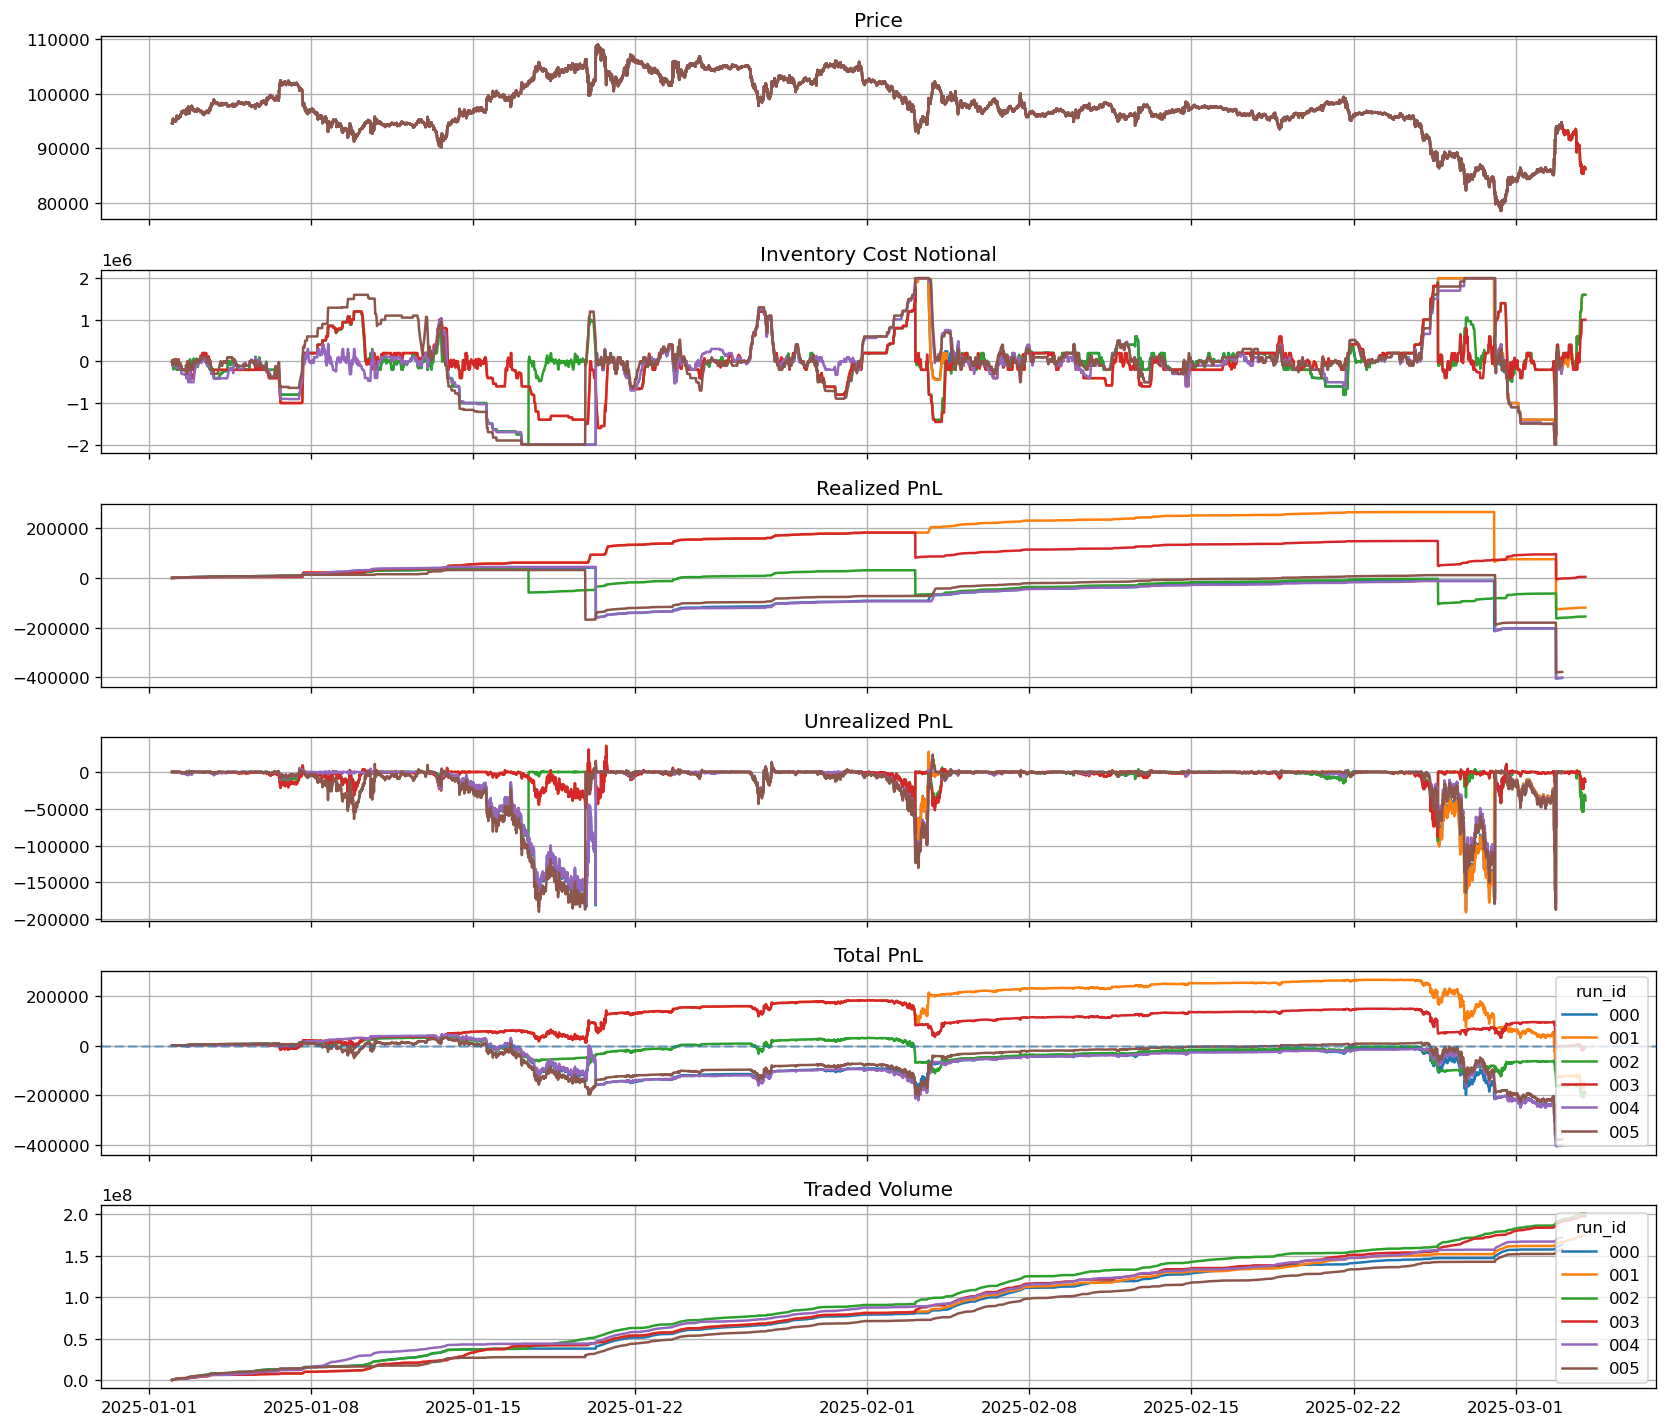

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,000,60,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p2x1p2__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mht...,-402823.367591,-0.197910,-5.712230,440001.214286,-2.513388e+06,-5.712230,-0.197910,2.689819e+06,-0.002468
1,001,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p2x1p2__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mht...,-158151.102460,-0.087627,-2.298059,423769.727933,-9.738479e+05,-2.298059,-0.087627,2.850298e+06,-0.000908
2,002,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p2x1p2__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mht...,-193970.692953,-0.128663,-5.195698,231148.539649,-1.200978e+06,-5.195698,-0.128663,3.275680e+06,-0.000965
3,003,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p2x1p2__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mht...,-9109.331555,-0.007096,-0.351050,191360.494738,-6.717717e+04,-0.351050,-0.007096,3.245344e+06,-0.000046
4,004,60,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p2x1p2__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__l...,-402378.046703,-0.190080,-5.643701,443562.184970,-2.503332e+06,-5.643701,-0.190080,2.857215e+06,-0.002340
5,005,60,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p2x1p2__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__l...,-378866.120016,-0.190180,-5.867549,403815.016200,-2.369404e+06,-5.867549,-0.190180,2.590988e+06,-0.002403


batch 2: run_id 006..011


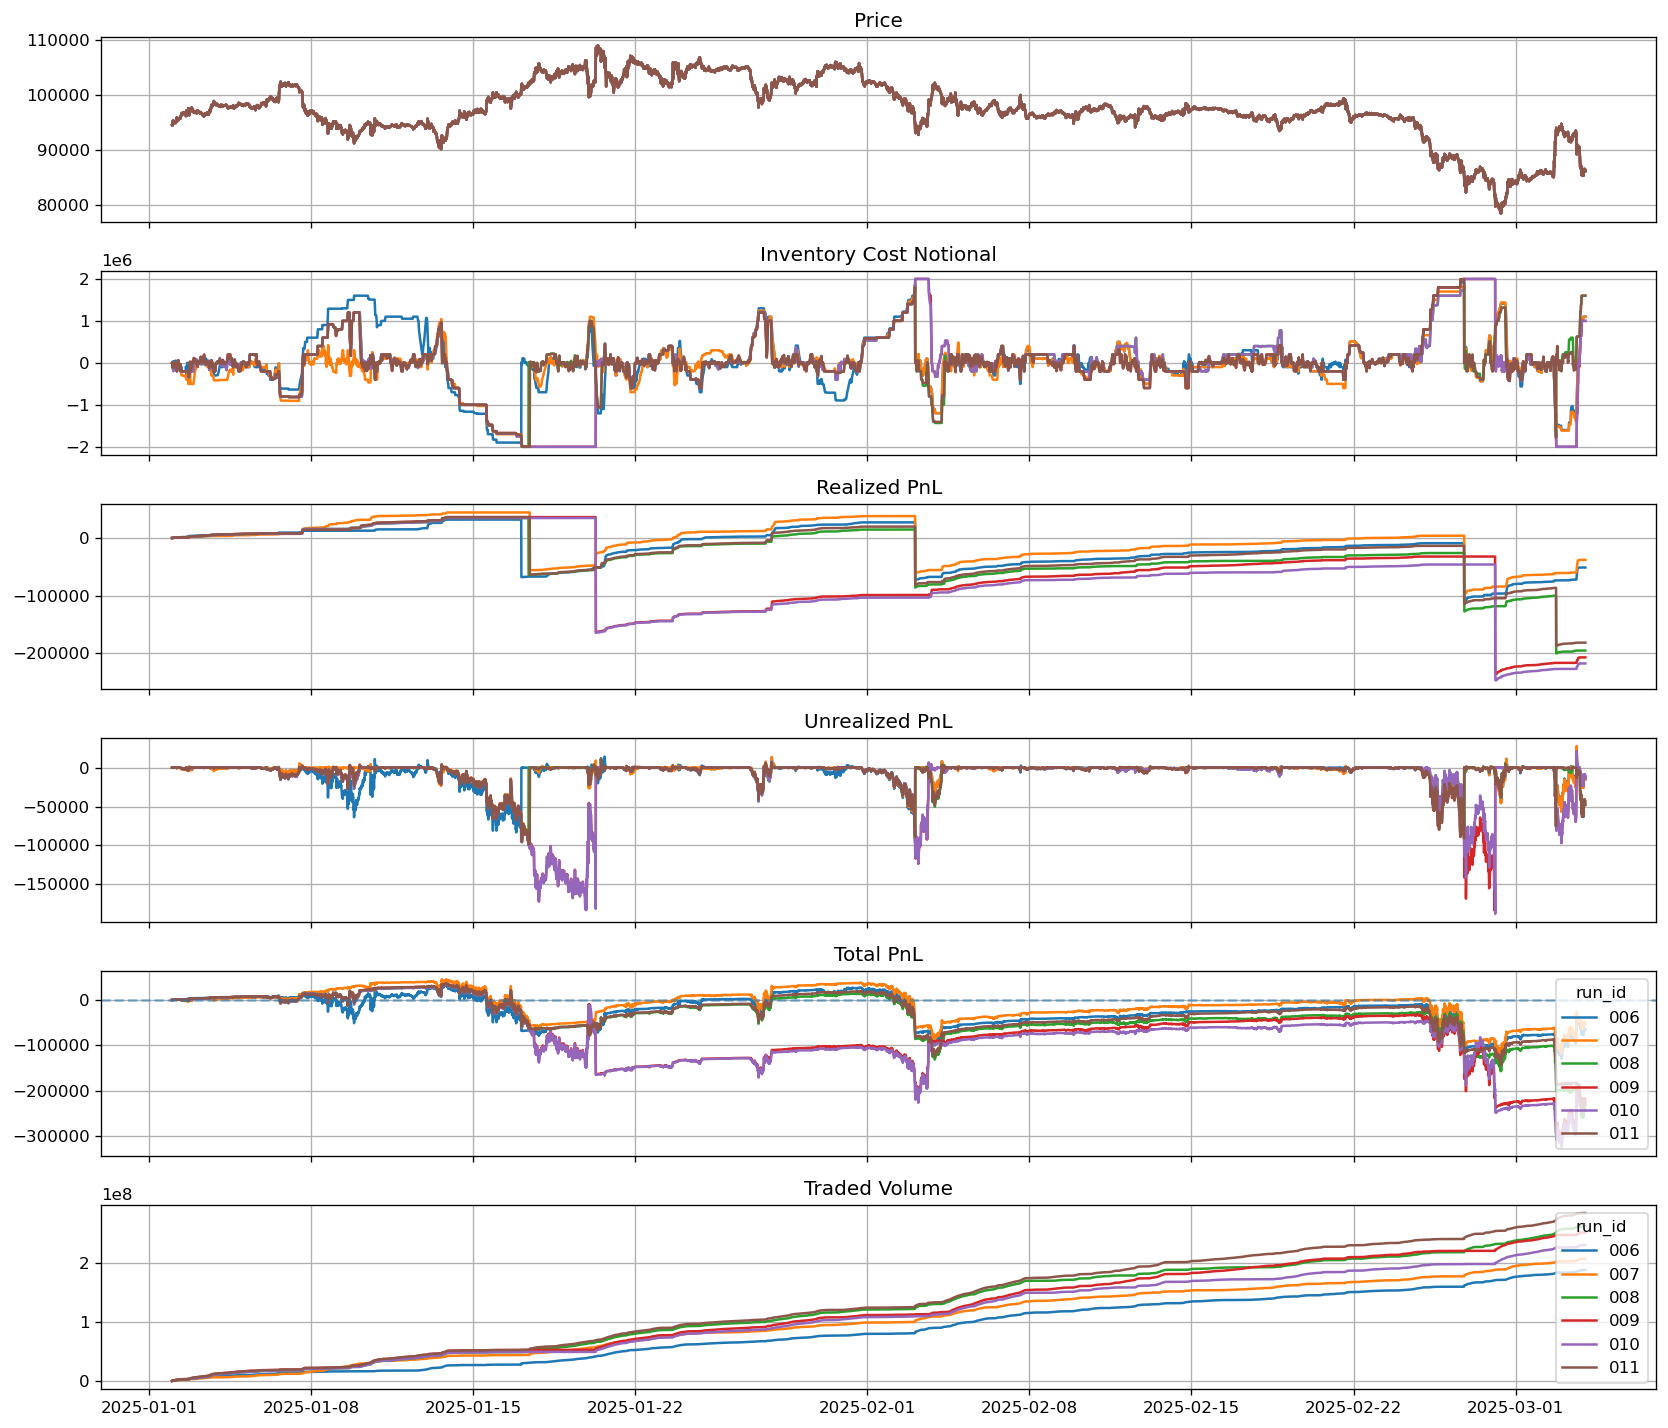

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,006,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p2x1p2__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__l...,-66481.612908,-0.055762,-2.975194,144385.636663,-4.295753e+05,-2.975194,-0.055762,3.041925e+06,-0.000355
1,007,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p2x1p2__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__l...,-53251.817233,-0.043976,-2.260136,149441.857186,-3.377589e+05,-2.260136,-0.043976,3.381664e+06,-0.000258
2,008,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p2x1p2__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mht...,-243502.731087,-0.166420,-5.471292,273935.548010,-1.498781e+06,-5.471292,-0.166420,4.279707e+06,-0.000932
3,009,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p2x1p2__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mht...,-220646.553449,-0.118668,-4.075257,333985.546881,-1.361077e+06,-4.075257,-0.118668,4.081222e+06,-0.000880
4,010,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p2x1p2__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mht...,-231157.855600,-0.122376,-4.154725,342666.097960,-1.423683e+06,-4.154725,-0.122376,3.752245e+06,-0.001007
5,011,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p2x1p2__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mht...,-229802.070443,-0.163554,-5.410827,261840.362011,-1.416773e+06,-5.410827,-0.163554,4.627369e+06,-0.000810


batch 3: run_id 012..017


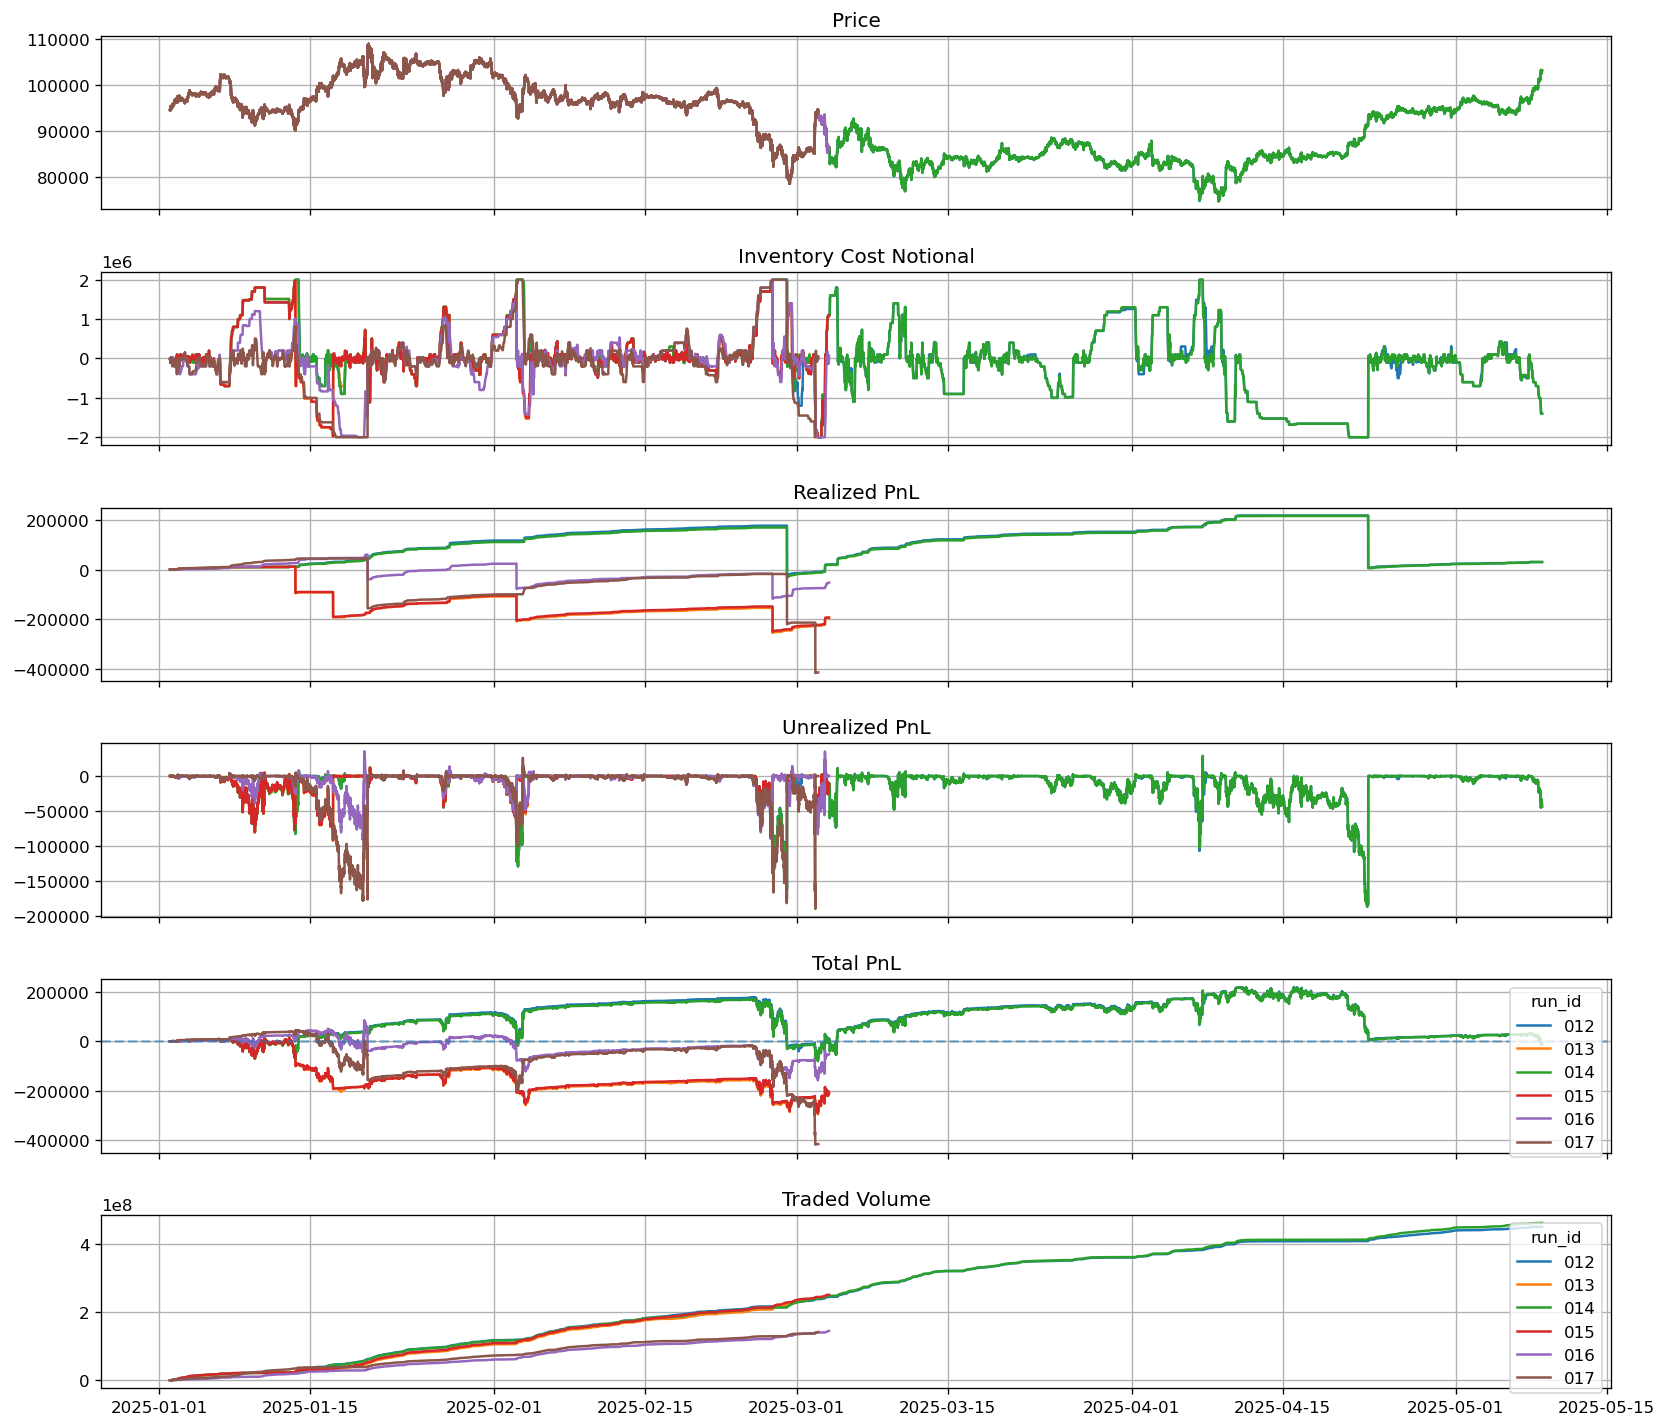

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,012,127,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p2x1p2__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__l...,-12954.996684,-0.005432,-0.196338,241036.078669,-4.732466e+04,-0.196338,-0.005432,3.507911e+06,-0.000029
1,013,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p2x1p2__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__l...,-209844.209423,-0.130779,-4.480796,288868.676633,-1.294362e+06,-4.480796,-0.130779,4.031402e+06,-0.000846
2,014,127,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p2x1p2__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__l...,-12786.390576,-0.005280,-0.193016,235838.545942,-4.552059e+04,-0.193016,-0.005280,3.604261e+06,-0.000028
3,015,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p2x1p2__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__l...,-208014.834691,-0.130477,-4.483939,286800.497434,-1.285996e+06,-4.483939,-0.130477,4.050139e+06,-0.000831
4,016,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mht...,-52290.623810,-0.031325,-1.600684,201916.389817,-3.232043e+05,-1.600684,-0.031325,2.379043e+06,-0.000361
5,017,60,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mht...,-414896.294598,-0.201155,-5.691173,456428.355048,-2.597613e+06,-5.691173,-0.201155,2.336338e+06,-0.002927


batch 4: run_id 018..023


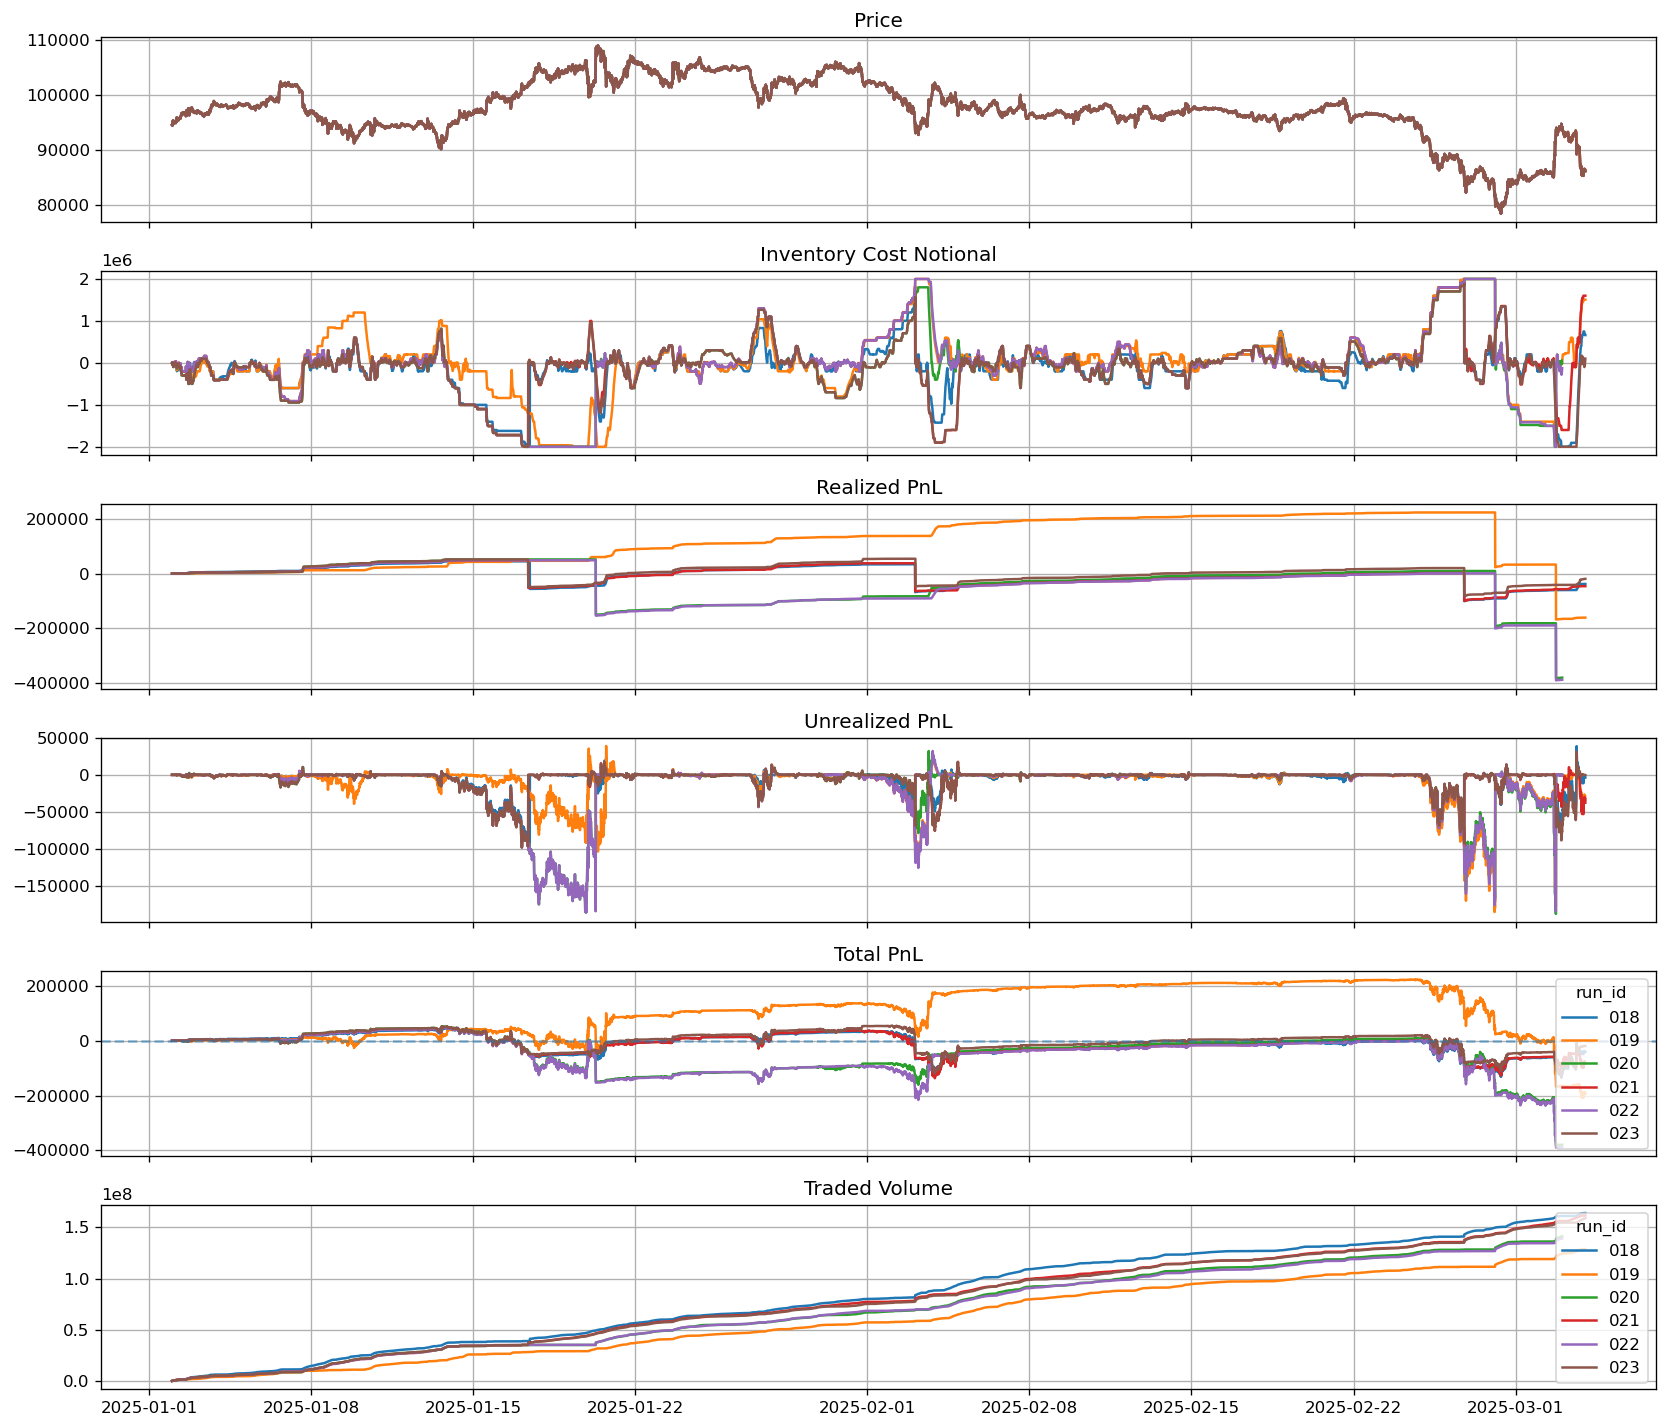

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,018,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mht...,-41035.692421,-0.030413,-1.701178,164592.295834,-2.800007e+05,-1.701178,-0.030413,2.670480e+06,-0.000250
1,019,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mht...,-194136.608289,-0.101611,-2.848879,416339.436321,-1.186101e+06,-2.848879,-0.101611,2.114599e+06,-0.001506
2,020,60,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__l...,-379503.423805,-0.183014,-5.544729,427508.184114,-2.370417e+06,-5.544729,-0.183014,2.338742e+06,-0.002685
3,021,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__l...,-83104.178844,-0.060159,-3.215986,164075.043490,-5.276630e+05,-3.215986,-0.060159,2.638231e+06,-0.000514
4,022,60,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__l...,-387288.502972,-0.182792,-5.596266,432149.676001,-2.418425e+06,-5.596266,-0.182792,2.302460e+06,-0.002782
5,023,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__l...,-18935.609833,-0.012280,-0.805795,170584.026904,-1.374558e+05,-0.805795,-0.012280,2.595581e+06,-0.000119


batch 5: run_id 024..029


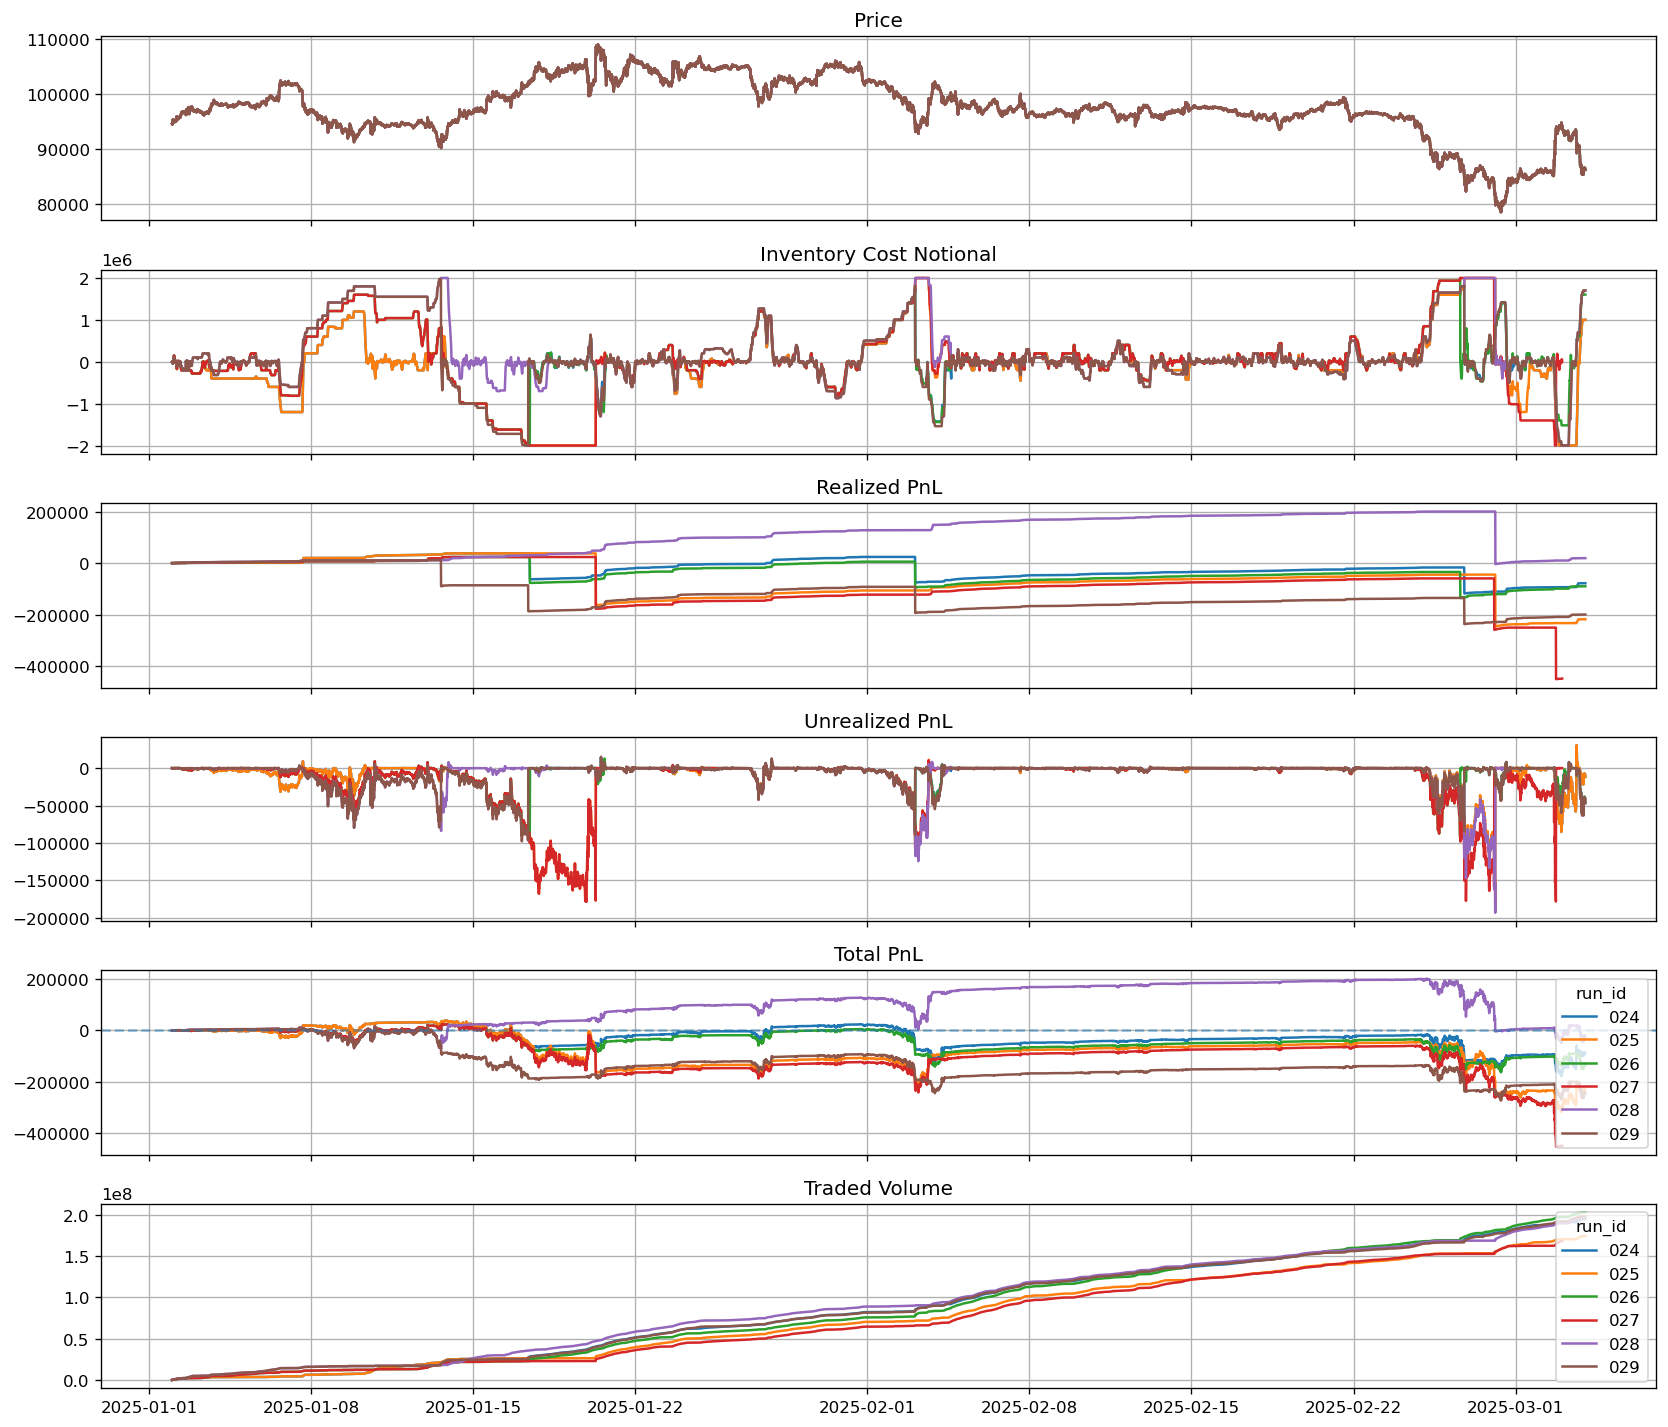

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,024,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mht...,-90022.260194,-0.057668,-2.735430,200552.690620,-5.485979e+05,-2.735430,-0.057668,3.205221e+06,-0.000462
1,025,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mht...,-230124.370522,-0.116949,-4.112332,340654.800948,-1.400886e+06,-4.112332,-0.116949,2.859704e+06,-0.001322
2,026,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mht...,-135434.556704,-0.108192,-5.302026,155585.060816,-8.249161e+05,-5.302026,-0.108192,3.340708e+06,-0.000668
3,027,60,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mht...,-449143.479784,-0.213104,-5.923024,469293.983896,-2.779639e+06,-5.923024,-0.213104,2.810296e+06,-0.002670
4,028,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__l...,-27269.857966,-0.022002,-0.778099,235203.140365,-1.830112e+05,-0.778099,-0.022002,3.177026e+06,-0.000140
5,029,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__l...,-246657.844860,-0.163359,-5.775376,262774.506167,-1.517621e+06,-5.775376,-0.163359,3.219189e+06,-0.001246


batch 6: run_id 030..035


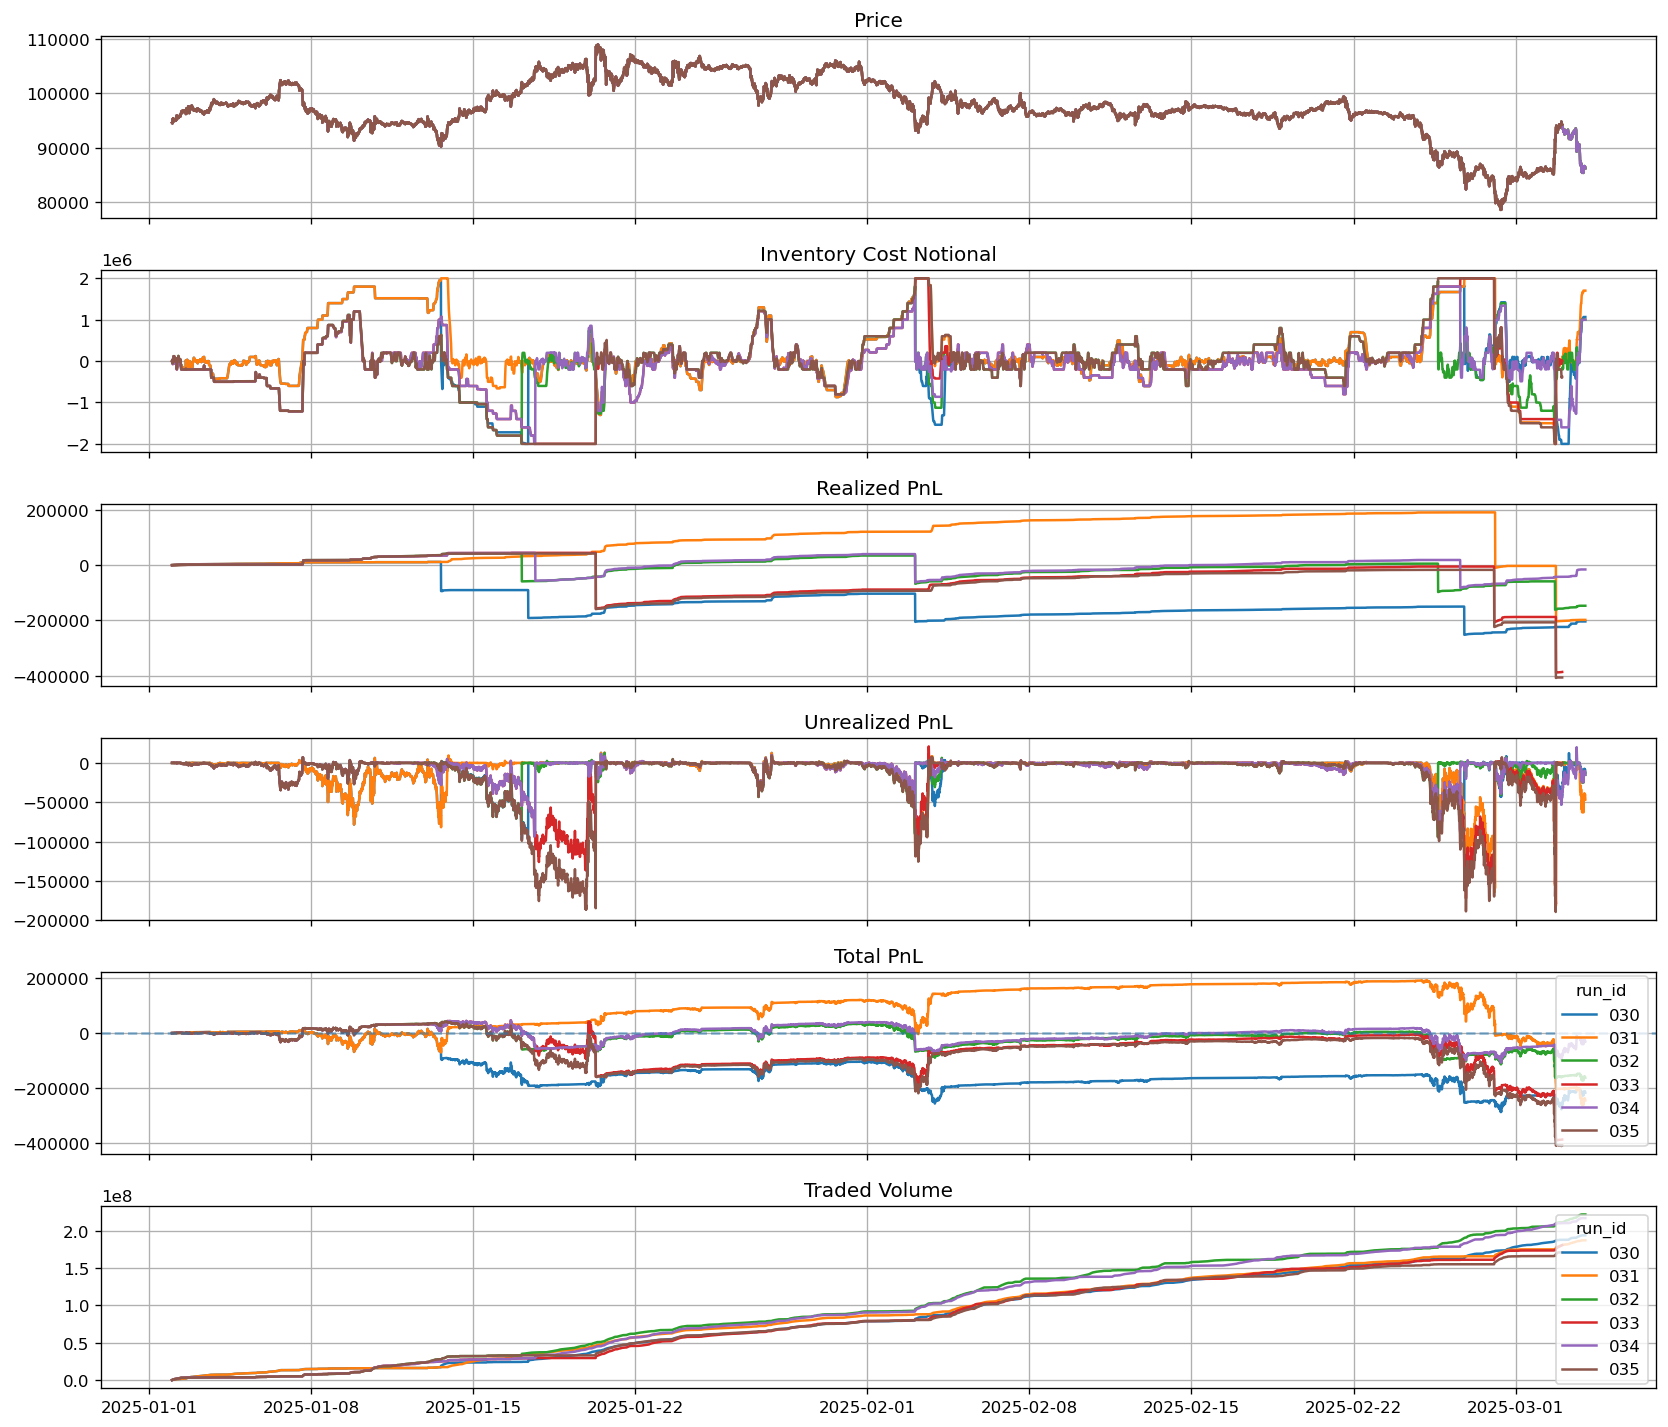

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,030,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__l...,-216102.476939,-0.139292,-4.943312,269780.532067,-1.333609e+06,-4.943312,-0.139292,3.156649e+06,-0.001114
1,031,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__l...,-244508.098768,-0.131649,-3.482406,432577.430176,-1.506410e+06,-3.482406,-0.131649,3.045601e+06,-0.001305
2,032,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__...,-162159.636817,-0.116545,-4.945948,199454.609265,-9.864922e+05,-4.945948,-0.116545,3.646403e+06,-0.000730
3,033,60,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__...,-386338.475420,-0.176054,-5.561163,429572.434513,-2.388923e+06,-5.561163,-0.176054,3.012588e+06,-0.002135
4,034,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__...,-30579.957601,-0.022826,-1.431177,129200.982152,-1.849095e+05,-1.431177,-0.022826,3.564922e+06,-0.000141
5,035,60,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__...,-407488.953068,-0.195760,-5.667758,444783.925516,-2.520928e+06,-5.667758,-0.195760,2.848794e+06,-0.002379


batch 7: run_id 036..041


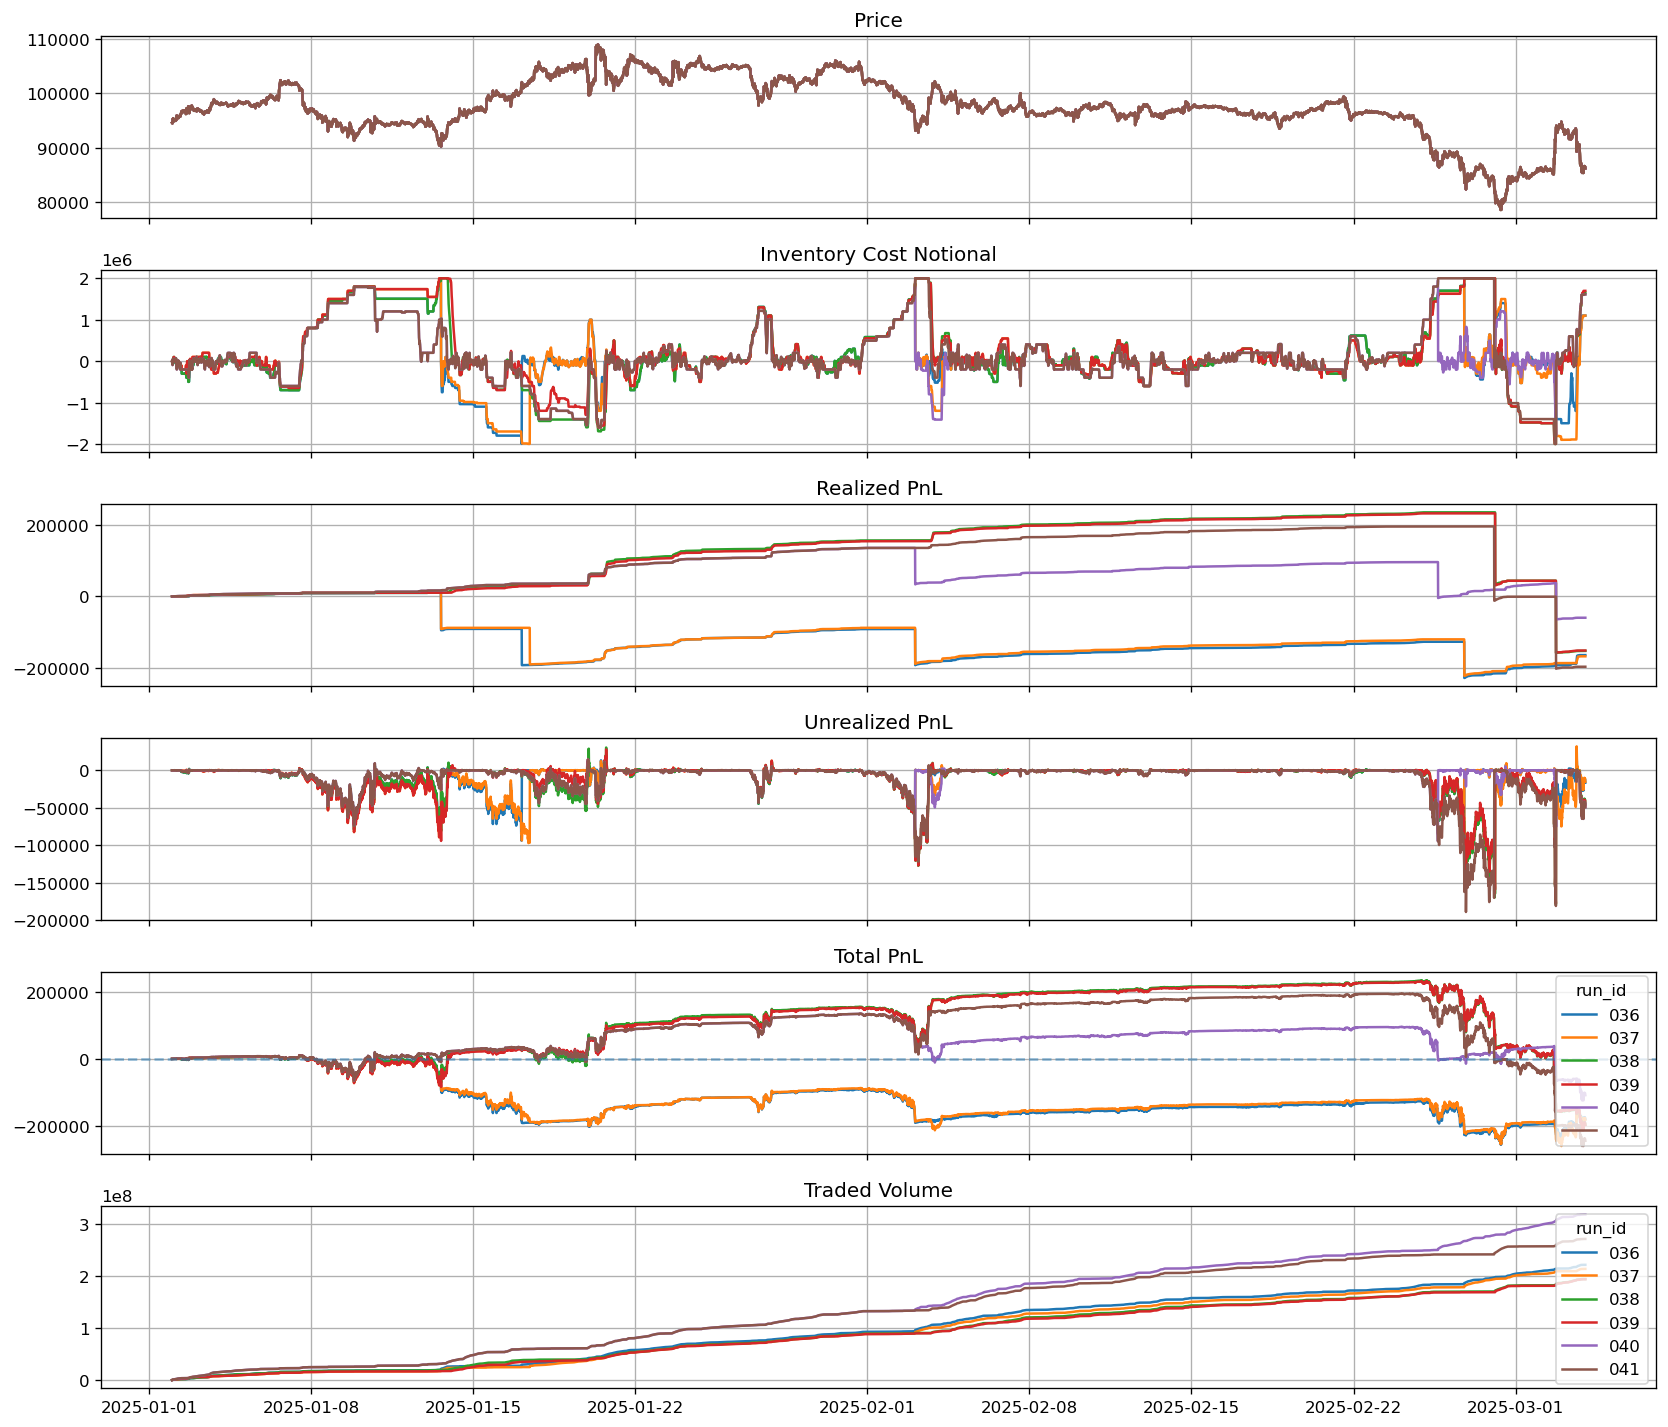

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,036,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi30...,-179530.836114,-0.132032,-4.663490,237725.305647,-1.108630e+06,-4.663490,-0.132032,3.619974e+06,-0.000811
1,037,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi30...,-181773.694358,-0.121531,-4.401536,256117.145952,-1.127309e+06,-4.401536,-0.121531,3.464078e+06,-0.000851
2,038,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi30...,-196950.868189,-0.102315,-2.841504,427450.182000,-1.214602e+06,-2.841504,-0.102315,3.165182e+06,-0.001015
3,039,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi30...,-197417.719087,-0.105237,-2.873474,425435.080846,-1.222477e+06,-2.873474,-0.105237,3.132679e+06,-0.001020
4,040,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__...,-108484.561854,-0.073753,-2.811707,241722.064072,-6.796517e+05,-2.811707,-0.073753,5.189658e+06,-0.000341
5,041,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__...,-244905.017712,-0.136435,-3.432704,439753.260562,-1.509543e+06,-3.432704,-0.136435,4.405014e+06,-0.000903


batch 8: run_id 042..047


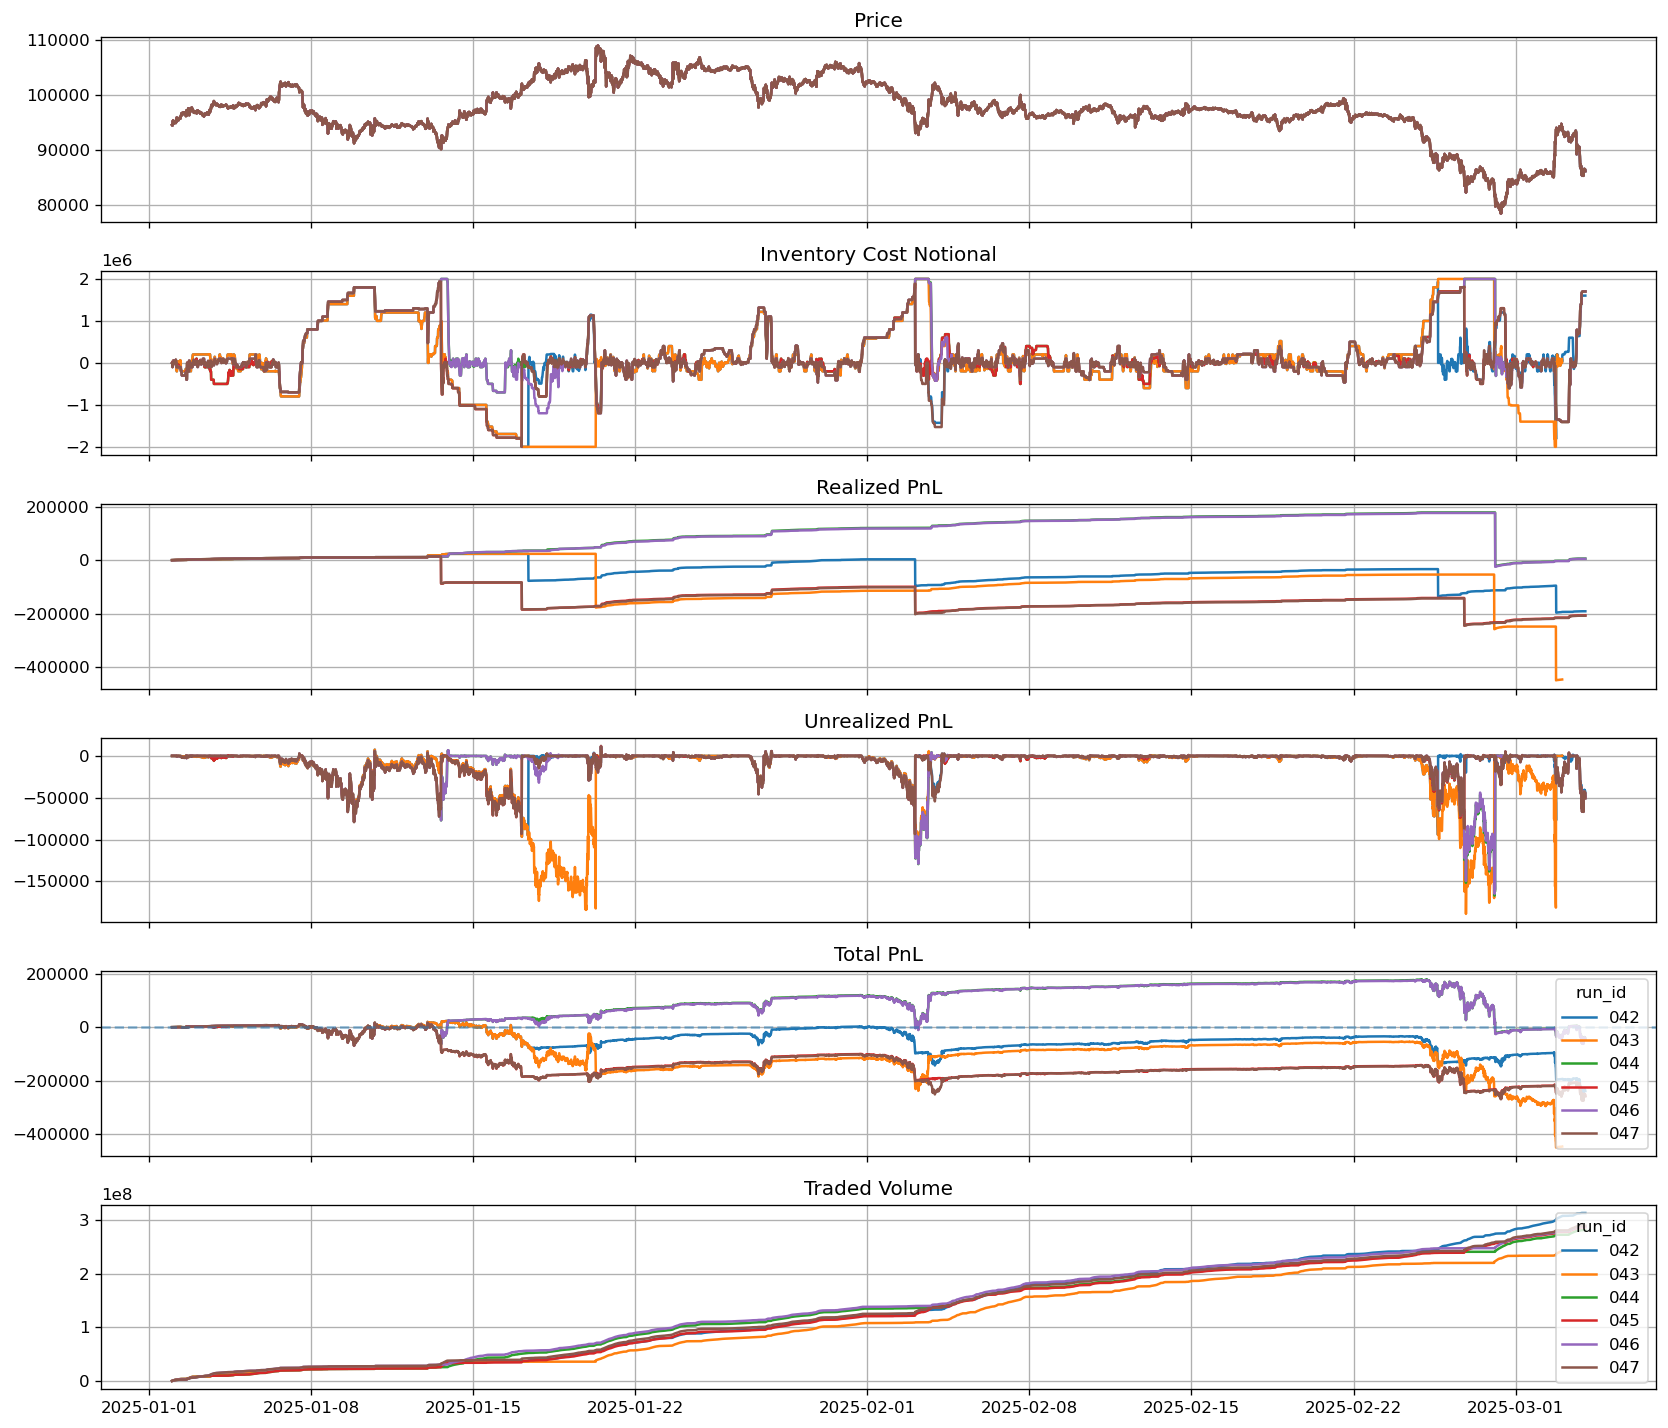

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,042,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__...,-238457.371658,-0.156250,-5.694470,257476.136755,-1.466190e+06,-5.694470,-0.156250,5.085642e+06,-0.000761
1,043,60,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__...,-445048.660546,-0.215208,-5.967033,464067.425643,-2.769105e+06,-5.967033,-0.215208,3.979177e+06,-0.001833
2,044,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi30...,-44502.392198,-0.037140,-1.320504,219004.465039,-2.891964e+05,-1.320504,-0.037140,4.574540e+06,-0.000158
3,045,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi30...,-256383.341232,-0.201112,-6.022696,262031.943620,-1.578139e+06,-6.022696,-0.201112,4.662987e+06,-0.000895
4,046,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi30...,-45505.910417,-0.037287,-1.343001,217794.821131,-2.924986e+05,-1.343001,-0.037287,4.691234e+06,-0.000158
5,047,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi30...,-257752.149991,-0.174791,-5.995182,264155.975053,-1.583663e+06,-5.995182,-0.174791,4.714165e+06,-0.000890


,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,003,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p2x1p2__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mht...,-9109.331555,-0.007096,-0.351050,191360.494738,-6.717717e+04,-0.351050,-0.007096,3.245344e+06,-0.000046
1,014,127,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p2x1p2__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__l...,-12786.390576,-0.005280,-0.193016,235838.545942,-4.552059e+04,-0.193016,-0.005280,3.604261e+06,-0.000028
2,012,127,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p2x1p2__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__l...,-12954.996684,-0.005432,-0.196338,241036.078669,-4.732466e+04,-0.196338,-0.005432,3.507911e+06,-0.000029
3,023,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__l...,-18935.609833,-0.012280,-0.805795,170584.026904,-1.374558e+05,-0.805795,-0.012280,2.595581e+06,-0.000119
4,028,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__l...,-27269.857966,-0.022002,-0.778099,235203.140365,-1.830112e+05,-0.778099,-0.022002,3.177026e+06,-0.000140
5,034,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__...,-30579.957601,-0.022826,-1.431177,129200.982152,-1.849095e+05,-1.431177,-0.022826,3.564922e+06,-0.000141
6,018,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mht...,-41035.692421,-0.030413,-1.701178,164592.295834,-2.800007e+05,-1.701178,-0.030413,2.670480e+06,-0.000250
7,044,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi30...,-44502.392198,-0.037140,-1.320504,219004.465039,-2.891964e+05,-1.320504,-0.037140,4.574540e+06,-0.000158
8,046,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi30...,-45505.910417,-0.037287,-1.343001,217794.821131,-2.924986e+05,-1.343001,-0.037287,4.691234e+06,-0.000158
9,016,61,/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bp0x10__bt1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mht...,-52290.623810,-0.031325,-1.600684,201916.389817,-3.232043e+05,-1.600684,-0.031325,2.379043e+06,-0.000361


In [5]:
plot_df = choose_folders(limit=MAX_FOLDERS)
all_metrics = []

for start in range(0, len(plot_df), BATCH_SIZE):
    batch = plot_df.iloc[start : start + BATCH_SIZE]
    first_id = int(batch["run_id"].iloc[0])
    last_id = int(batch["run_id"].iloc[-1])
    print(f"batch {start // BATCH_SIZE + 1}: run_id {first_id:03d}..{last_id:03d}")
    all_metrics.append(plot_folder_batch(batch))

summary_df = pd.concat(all_metrics, ignore_index=True) if all_metrics else pd.DataFrame()
display(summary_df.sort_values("pnls", ascending=False).reset_index(drop=True))

In [6]:
folders[31]

'/data/users/kang/backtest/glftmm_tier/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bp0x20__bt1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1x1__bu10x0__cc1x1x1__fr1000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp100000x200000x300000x400000x500000x600000x700000x800000x900000x1000000x1100000__hdae238512b/strat__all'

Inspect one folder with the full report panels.

Compare selected folders on one PnL chart.